# How to classify satellite images

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications.densenet import DenseNet201
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam

import tensorflow_datasets as tfds

In [3]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
if gpu_devices:
    print("Using GPU")
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("Using CPU")

Using CPU


In [4]:
sns.set_style("whitegrid")

In [5]:
results_path = Path("results", "eurosat")
if not results_path.exists():
    results_path.mkdir(parents=True)

## Load EuroSat Dataset

In [6]:
(raw_train, raw_validation), metadata = tfds.load(
    "eurosat",
    split=[
        "train[:90%]",
        "train[90%:]"
    ],
    with_info=True,
    shuffle_files=False,
    as_supervised=True,
    data_dir="../data/tensorflow",
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling ..\data\tensorflow\eurosat\rgb\incomplete.2FJ8KW_2.0.0\eurosat-train.tfrecord*...:   0%|          | …

Dataset eurosat downloaded and prepared to ..\data\tensorflow\eurosat\rgb\2.0.0. Subsequent calls will reuse this data.


### Inspect MetaData

In [7]:
metadata

tfds.core.DatasetInfo(
    name='eurosat',
    full_name='eurosat/rgb/2.0.0',
    description="""
    EuroSAT dataset is based on Sentinel-2 satellite images covering 13 spectral
    bands and consisting of 10 classes with 27000 labeled and
    geo-referenced samples.
    
    Two datasets are offered:
    - rgb: Contains only the optical R, G, B frequency bands encoded as JPEG image.
    - all: Contains all 13 bands in the original value range (float32).
    
    URL: https://github.com/phelber/eurosat
    """,
    config_description="""
    Sentinel-2 RGB channels
    """,
    homepage='https://github.com/phelber/eurosat',
    data_dir='..\\data\\tensorflow\\eurosat\\rgb\\2.0.0',
    file_format=tfrecord,
    download_size=89.91 MiB,
    dataset_size=89.50 MiB,
    features=FeaturesDict({
        'filename': Text(shape=(), dtype=string),
        'image': Image(shape=(64, 64, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_k

In [8]:
print("Train:\t", raw_train)
print("Valid:\t", raw_validation)

Train:	 <_PrefetchDataset element_spec=(TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Valid:	 <_PrefetchDataset element_spec=(TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


### Show sample images

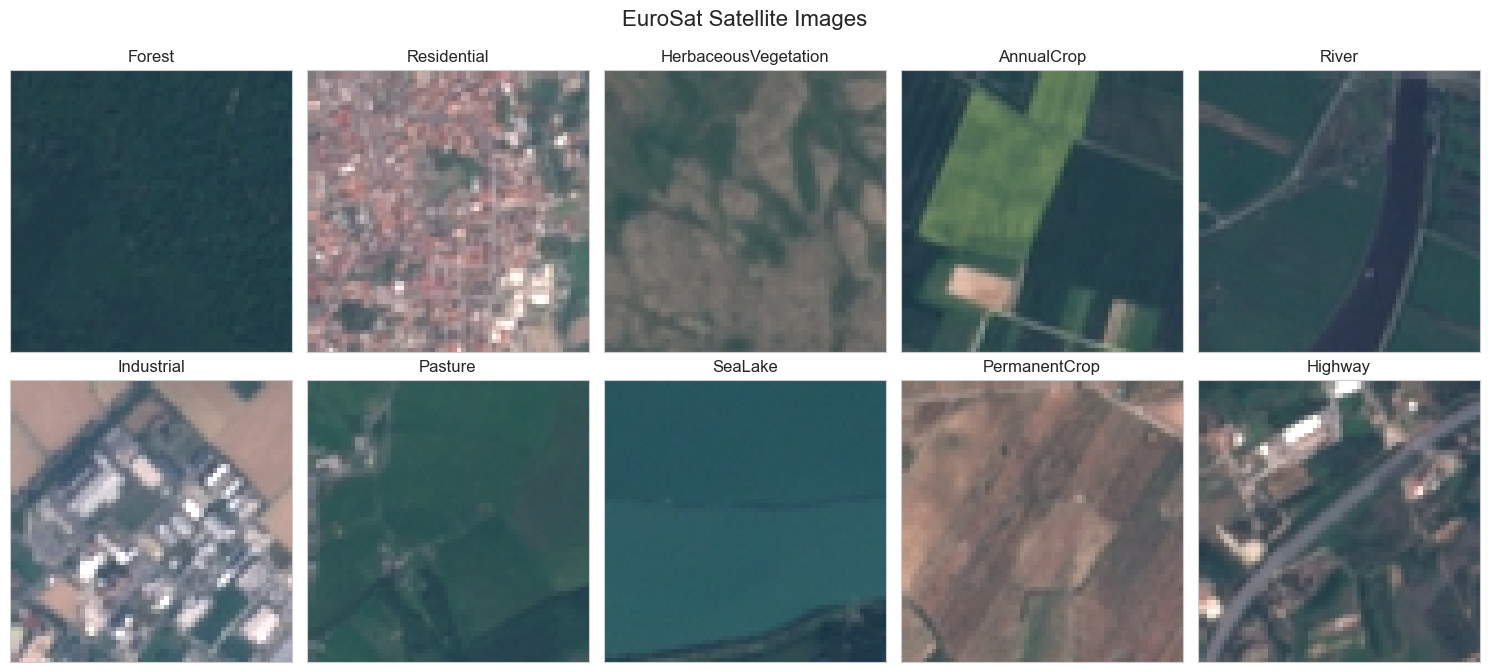

In [9]:
fig, axes = plt.subplots(figsize=(15, 7), ncols=5, nrows=2)
axes = axes.flatten()
get_label_name = metadata.features["label"].int2str
labels = set()
c = 0
for img, label in raw_train.as_numpy_iterator():
    if label not in labels:
        axes[c].imshow(img)
        axes[c].set_title(get_label_name(label))
        axes[c].grid(False)
        axes[c].tick_params(
            axis="both",
            which="both",
            bottom=False,
            top=False,
            labelbottom=False,
            right=False,
            left=False,
            labelleft=False,
        )
        labels.add(label)
        c += 1
        if c == 10:
            break
fig.suptitle("EuroSat Satellite Images", fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=0.92);
# fig.savefig(results_path / 'eurosat_samples', dpi=300);

## Preprocessing

All images will be resized to 160x160:

In [10]:
IMG_SIZE = 64
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

In [11]:
def format_example(image, label):
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1
    return image, label

In [12]:
train = raw_train.map(format_example)
validation = raw_validation.map(format_example)

In [13]:
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

In [14]:
train_batches = train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
validation_batches = validation.batch(BATCH_SIZE)

In [15]:
for image_batch, label_batch in train_batches.take(1):
    pass

image_batch.shape

TensorShape([32, 64, 64, 3])

## Load the DenseNet201 Bottleneck Features

In [16]:
densenet = DenseNet201(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet",
    pooling="max",
    classes=1000,
)

densenet.summary()

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "densenet201"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 70, 70, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 16,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 16, 16,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 16, 16,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 16, 16,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 16, 16,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 16, 16,    │     12,288 │ conv2_block2_0_r

 Total params: 18,321,984 (69.89 MB)

 Trainable params: 18,092,928 (69.02 MB)

 Non-trainable params: 229,056 (894.75 KB)

In [17]:
feature_batch = densenet(image_batch)
feature_batch.shape

TensorShape([32, 1920])

In [18]:
len(densenet.layers)

708

## Add new layers to model

In [19]:
model = Sequential(
    [
        densenet,
        BatchNormalization(),
        Dense(2048, activation="relu", kernel_regularizer=l1_l2(0.01)),
        BatchNormalization(),
        Dense(2048, activation="relu", kernel_regularizer=l1_l2(0.01)),
        BatchNormalization(),
        Dense(2048, activation="relu", kernel_regularizer=l1_l2(0.01)),
        BatchNormalization(),
        Dense(2048, activation="relu", kernel_regularizer=l1_l2(0.01)),
        BatchNormalization(),
        Dense(10, activation="softmax"),
    ]
)

In [20]:
for layer in model.layers:
    layer.trainable = True

In [22]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-4),
    metrics=["accuracy"],
)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 1920)           │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1920)           │         7,680 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     3,934,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,906,186 (133.16 MB)

 Trainable params: 34,656,906 (132.21 MB)

 Non-trainable params: 249,280 (973.75 KB)

### Compute baseline metrics

In [24]:
initial_epochs = 10
validation_steps = 20

initial_loss, initial_accuracy = model.evaluate(
    validation_batches, steps=validation_steps
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.1031 - loss: 3175.3013


In [25]:
print(
    f"Initial loss: {initial_loss:.2f} | initial_accuracy accuracy: {initial_accuracy:.2%}"
)

Initial loss: 3175.30 | initial_accuracy accuracy: 10.16%


## Train model

### Define Callbacks

In [26]:
early_stopping = EarlyStopping(monitor="val_accuracy", patience=10)

In [28]:
eurosat_path = (results_path / "cnn.weights.best.keras").as_posix()
checkpointer = ModelCheckpoint(
    filepath=eurosat_path, verbose=1, monitor="val_accuracy", save_best_only=True
)

In [29]:
epochs = 100

In [30]:
history = model.fit(
    train_batches,
    epochs=epochs,
    validation_data=validation_batches,
    callbacks=[checkpointer, early_stopping],
)

Epoch 1/100
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.7507 - loss: 1542.0260
Epoch 1: val_accuracy improved from -inf to 0.92778, saving model to results/eurosat/cnn.weights.best.keras
760/760 ━━━━━━━━━━━━━━━━━━━━ 787s 946ms/step - accuracy: 0.7508 - loss: 1540.9015 - val_accuracy: 0.9278 - val_loss: 4.1870
Epoch 2/100
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9119 - loss: 2.8916
Epoch 2: val_accuracy did not improve from 0.92778
760/760 ━━━━━━━━━━━━━━━━━━━━ 1136s 1s/step - accuracy: 0.9119 - loss: 2.8911 - val_accuracy: 0.9189 - val_loss: 2.7361
Epoch 3/100
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9406 - loss: 2.5889
Epoch 3: val_accuracy improved from 0.92778 to 0.96111, saving model to results/eurosat/cnn.weights.best.keras
760/760 ━━━━━━━━━━━━━━━━━━━━ 993s 1s/step - accuracy: 0.9406 - loss: 2.5886 - val_accuracy: 0.9611 - val_loss: 2.4154
Epoch 4/100
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9683 - loss: 2.3609
Epoch 4: val_accura

### Plot Learning Curves

In [31]:
def plot_learning_curves(df):
    fig, axes = plt.subplots(ncols=2, figsize=(15, 4))
    df[["accuracy", "val_accuracy"]].plot(ax=axes[0], title="Accuracy")
    df[["loss", "val_loss"]].plot(ax=axes[1], title="Cross-Entropy")
    for ax in axes:
        ax.legend(["Training", "Validation"])
    fig.tight_layout()

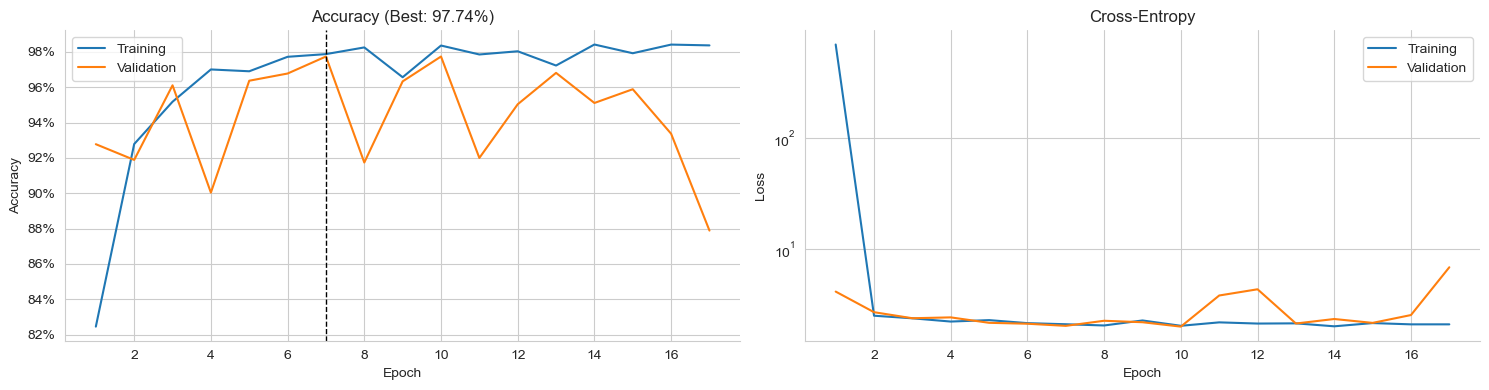

In [32]:
metrics = pd.DataFrame(history.history)
metrics.index = metrics.index.to_series().add(1)

fig, axes = plt.subplots(ncols=2, figsize=(15, 4))
metrics[["accuracy", "val_accuracy"]].plot(
    ax=axes[0], title=f"Accuracy (Best: {metrics.val_accuracy.max():.2%})"
)
axes[0].axvline(metrics.val_accuracy.idxmax(), ls="--", lw=1, c="k")
metrics[["loss", "val_loss"]].plot(ax=axes[1], title="Cross-Entropy", logy=True)
for ax in axes:
    ax.legend(["Training", "Validation"])
    ax.set_xlabel("Epoch")

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: "{:.0%}".format(y)))
axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Loss")
sns.despine()
fig.tight_layout()
fig.savefig(results_path / "satellite_accuracy", dpi=300);